In [1]:
from PIL import Image
import os


# 画像ファイルの名前を格納するリストを用意
list_file_name = []

# 画像データを格納するリストを用意
list_images = []

# 画像ファイルとPythonプログラムは同じ場所に置いたのでカレントディレクトリを指定
dir = '/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災データ/USA_Climate/Freq_per_year/'
for file_name in os.listdir(dir):
    # ファイル名の最後がJPGのものをリストに追加
    if file_name.endswith('png'):
        list_file_name.append(file_name)

# 念のため画像ファイル名の順番をソート
list_file_name.sort()
for s in range(len(list_file_name)):
    s1 = list_file_name[s]
    s2 = dir + s1
    list_file_name[s] = s2

print(list_file_name)

# 倍率0.25倍を指定
ratio = 1.4
for i in list_file_name:
    img = Image.open(i)
    # 画像のリサイズ
    resized_img = img.resize((int(img.width * ratio), int(img.height * ratio)))
    # 画像の回転
    rotated_resized_img = resized_img.rotate(0)
    list_images.append(rotated_resized_img)
list_images[0].save('/Users/kurozuhajime/Desktop/graph_freqperyear.gif',save_all=True, append_images=list_images[1:],
optimize=False, duration=1000, loop=2)

['/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災データ/USA_Climate/Freq_per_year/スクリーンショット 2024-09-06 0.22.28.png', '/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災データ/USA_Climate/Freq_per_year/スクリーンショット 2024-09-06 0.22.56.png', '/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災データ/USA_Climate/Freq_per_year/スクリーンショット 2024-09-06 0.23.05.png', '/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災データ/USA_Climate/Freq_per_year/スクリーンショット 2024-09-06 0.23.21.png', '/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災データ/USA_Climate/Freq_per_year/スクリーンショット 2024-09-06 0.23.40.png', '/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災データ/USA_Climate/Freq_per_year/スクリーンショット 2024-09-06 0.23.49.png', '/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災データ/USA_Climate/Freq_per_year/スクリーンショット 2024-09-06 0.24.05.png', '/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災データ/USA_Climate/Freq_per_year/スクリーンショット 2024-09-06 0.24.23.png', '/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災デー

      drought  flooding  freeze  severe storm state  tropical cyclone  \
year                                                                    
2015        0         1       0             5    TX                 0   
2016        0         2       0             7    TX                 0   
2017        0         1       0             6    TX                 1   
2018        1         0       0             5    TX                 0   
2019        0         1       0             5    TX                 1   
2020        1         0       0             7    TX                 3   
2021        0         1       0             9    TX                 1   
2022        1         0       0             7    TX                 0   
2023        1         0       0            15    TX                 0   
2024        1         0       0            16    TX                 2   

      wildfire  winter storm  
year                          
2015         1             0  
2016         0             0  

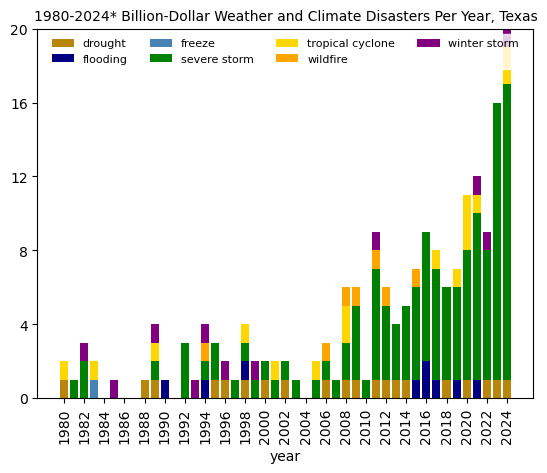

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df1 = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災データ/USA_Climate/US気候災害リスク評価.csv')

#print(df.columns)

clms = ['drought', 'flooding', 'freeze', 'severe storm', 'tropical cyclone', 'wildfire', 'winter storm']

this_year = 2024

x = range(1980, this_year+1)

#df = df1.pivot_table(index='year', aggfunc='sum')


df2 = df1[df1['state'] == 'TX']
#print(df2)
df3 = df2.pivot_table(index='year', aggfunc='sum')

print(df3.tail(10))

print(df3.sum(axis=1, numeric_only=True))
sevstm = df3[df3.index == 2024]['severe storm']
print(sevstm)

"""
plt.figure(facecolor='k')
ax = plt.axes()
ax.set_facecolor('k')
"""

#plt.title(f'1980-{this_year}* Billion-Dollar Weather and Climate Disasters Per Year, Texas', color='w', fontsize=10)
plt.title(f'1980-{this_year}* Billion-Dollar Weather and Climate Disasters Per Year, Texas', color='k', fontsize=10)

"""
plt.bar(x, df3['drought'], width=0.5, color='y', label='drought')
plt.bar(x, df3['flooding'], width=0.5, color='Navy',label='flooding', bottom=df3['drought'])
plt.bar(x, df3['freeze'], width=0.5, color='steelblue', label='freeze', bottom=df3['drought']+df3['flooding'])
plt.bar(x, df3['severe storm'], width=0.5, color='green', label='severe storm', bottom=df3['drought']+df3['flooding']+df3['freeze'])
plt.bar(x, df3['tropical cyclone'], width=0.5, color='navajowhite', label='tropical cyclone', bottom=df3['drought']+df3['flooding']+df3['freeze']+df3['severe storm'])
plt.bar(x, df3['wildfire'], width=0.5, color='orange', label='wildfire', bottom=df3['drought']+df3['flooding']+df3['freeze']+df3['severe storm']+df3['tropical cyclone'])
plt.bar(x, df3['winter storm'], width=0.5, color='purple', label='winter storm', bottom=df3['drought']+df3['flooding']+df3['freeze']+df3['severe storm']+df3['tropical cyclone']+df3['wildfire'])
"""


plt.bar(x, df3['drought'], width=0.8, color='darkgoldenrod', label='drought')
plt.bar(x, df3['flooding'], width=0.8, color='Navy',label='flooding', bottom=df3['drought'])
plt.bar(x, df3['freeze'], width=0.8, color='steelblue', label='freeze', bottom=df3['drought']+df3['flooding'])
plt.bar(x, df3['severe storm'], width=0.8, color='green', label='severe storm', bottom=df3['drought']+df3['flooding']+df3['freeze'])
plt.bar(x, df3['tropical cyclone'], width=0.8, color='gold', label='tropical cyclone', bottom=df3['drought']+df3['flooding']+df3['freeze']+df3['severe storm'])
plt.bar(x, df3['wildfire'], width=0.8, color='orange', label='wildfire', bottom=df3['drought']+df3['flooding']+df3['freeze']+df3['severe storm']+df3['tropical cyclone'])
plt.bar(x, df3['winter storm'], width=0.8, color='purple', label='winter storm', bottom=df3['drought']+df3['flooding']+df3['freeze']+df3['severe storm']+df3['tropical cyclone']+df3['wildfire'])



"""
ax.spines['left'].set_color('w')
ax.spines['bottom'].set_color('w')
# ラベルの色
ax.xaxis.label.set_color('w')
ax.yaxis.label.set_color('w')
# 目盛りの色
ax.tick_params(axis='x', colors='w')
ax.tick_params(axis='y', colors='w')
"""

plt.ylim(0, 20)

plt.xlabel('year',fontsize=10)
plt.xticks(df3.index[::2], fontsize=10, rotation=90)
plt.yticks(np.arange(0, 21, step=4))


#plt.ylabel('temperature anomaly (°C)',fontsize=10)
plt.legend(labelcolor="w",facecolor='k', edgecolor='k', framealpha=0.8, ncol=4, loc='upper center', fontsize=8)
plt.legend(labelcolor="k",facecolor='w', edgecolor='w', framealpha=0.8, ncol=4, loc='upper center', fontsize=8)

plt.show()



drought                 542
flooding                202
freeze                   74
severe storm           1743
tropical cyclone        393
wildfire                188
winter storm            397
year                4864860
Total                  3539
dtype: int64
       drought  flooding  freeze  severe storm  tropical cyclone  wildfire  \
state                                                                        
TX          20         9       1           126                16         7   

       winter storm   year  Total  
state                              
TX               11  90090    190  


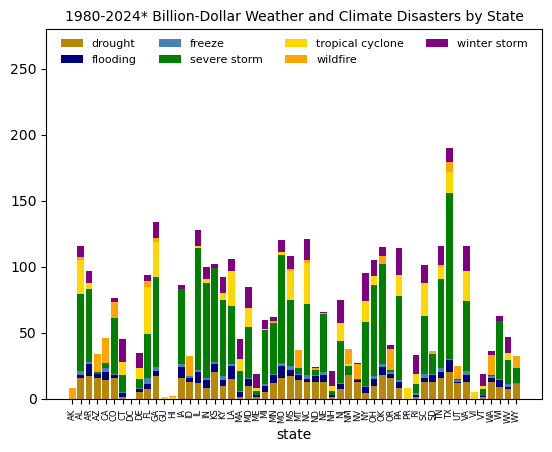

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df1 = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災データ/USA_Climate/US気候災害リスク評価.csv')

#print(df.columns)

clms = ['drought', 'flooding', 'freeze', 'severe storm', 'tropical cyclone', 'wildfire', 'winter storm']

this_year = 2024

x = range(1980, this_year+1)

#df = df1.pivot_table(index='year', aggfunc='sum')


#df2 = df1[df1['state'] == 'TX']
#print(df2)
df2 = df1.pivot_table(index='state', aggfunc='sum')
#print(df2)
#df3 = df2.sort()

#print(df3.tail(10))

df4 = df2[['drought', 'flooding', 'freeze', 'severe storm', 'tropical cyclone', 'wildfire', 'winter storm']].sum(axis=1)
#print(df4)

df3_d = pd.concat([df2, df4], axis=1)
df3_d.columns = ['drought', 'flooding', 'freeze', 'severe storm', 'tropical cyclone', 'wildfire', 'winter storm', 'year','Total']
#print(df3.iloc[:,4:])
df3 = df3_d.sort_values('Total',ascending=False)
df3 = df3_d

print(df3.sum())

sevstm = df3[df3.index == 'TX']
print(sevstm)



"""
plt.figure(facecolor='k')
ax = plt.axes()
ax.set_facecolor('k')
"""

#plt.title(f'1980-{this_year}* Billion-Dollar Weather and Climate Disasters by State', color='w', fontsize=10)
plt.title(f'1980-{this_year}* Billion-Dollar Weather and Climate Disasters by State', color='k', fontsize=10)

"""
plt.bar(df3.index, df3['drought'], width=0.8,  label='drought')
plt.bar(df3.index, df3['flooding'], width=0.8, label='flooding', bottom=df3['drought'])
plt.bar(df3.index, df3['freeze'], width=0.8,  label='freeze', bottom=df3['drought']+df3['flooding'])
plt.bar(df3.index, df3['severe storm'], width=0.8,  label='severe storm', bottom=df3['drought']+df3['flooding']+df3['freeze'])
plt.bar(df3.index, df3['tropical cyclone'], width=0.8,  label='tropical cyclone', bottom=df3['drought']+df3['flooding']+df3['freeze']+df3['severe storm'])
plt.bar(df3.index, df3['wildfire'], width=0.8,  label='wildfire', bottom=df3['drought']+df3['flooding']+df3['freeze']+df3['severe storm']+df3['tropical cyclone'])
plt.bar(df3.index, df3['winter storm'], width=0.8,  label='winter storm', bottom=df3['drought']+df3['flooding']+df3['freeze']+df3['severe storm']+df3['tropical cyclone']+df3['wildfire'])
"""

plt.bar(df3.index, df3['drought'], width=0.8, color='darkgoldenrod', label='drought')
plt.bar(df3.index, df3['flooding'], width=0.8, color='Navy',label='flooding', bottom=df3['drought'])
plt.bar(df3.index, df3['freeze'], width=0.8, color='steelblue', label='freeze', bottom=df3['drought']+df3['flooding'])
plt.bar(df3.index, df3['severe storm'], width=0.8, color='green', label='severe storm', bottom=df3['drought']+df3['flooding']+df3['freeze'])
plt.bar(df3.index, df3['tropical cyclone'], width=0.8, color='gold', label='tropical cyclone', bottom=df3['drought']+df3['flooding']+df3['freeze']+df3['severe storm'])
plt.bar(df3.index, df3['wildfire'], width=0.8, color='orange', label='wildfire', bottom=df3['drought']+df3['flooding']+df3['freeze']+df3['severe storm']+df3['tropical cyclone'])
plt.bar(df3.index, df3['winter storm'], width=0.8, color='purple', label='winter storm', bottom=df3['drought']+df3['flooding']+df3['freeze']+df3['severe storm']+df3['tropical cyclone']+df3['wildfire'])

"""
ax.spines['left'].set_color('w')
ax.spines['bottom'].set_color('w')
# ラベルの色
ax.xaxis.label.set_color('w')
ax.yaxis.label.set_color('w')
# 目盛りの色
ax.tick_params(axis='x', colors='w')
ax.tick_params(axis='y', colors='w')
"""

plt.ylim(0, 280)

plt.xlabel('state',fontsize=10)
plt.xticks(df3.index, fontsize=6, rotation=90)
#plt.yticks(np.arange(0, 21, step=4))


#plt.ylabel('temperature anomaly (°C)',fontsize=10)
#plt.legend(labelcolor="w",facecolor='k', edgecolor='k', framealpha=0.8, ncol=4, loc='upper center', fontsize=8)
plt.legend(labelcolor="k",facecolor='w', edgecolor='w', framealpha=0.8, ncol=4, loc='upper center', fontsize=8)
plt.show()


drought                                                           542
flooding                                                          202
freeze                                                             74
severe storm                                                     1743
state               AKALARAZCACOCTDCDEFLGAGUHIIAIDILINKSKYLAMAMDME...
tropical cyclone                                                  393
wildfire                                                          188
winter storm                                                      397
dtype: object
year
2024    183
Name: severe storm, dtype: int64
271
3539
year
2024    0.675277
Name: severe storm, dtype: float64
year
2023    178
Name: severe storm, dtype: int64
242
3539
year
2023    0.735537
Name: severe storm, dtype: float64


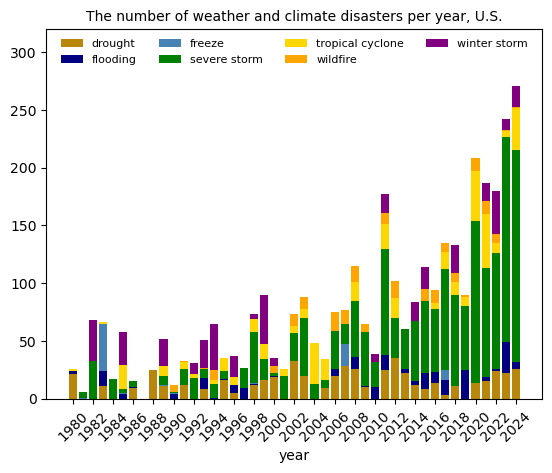

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df1 = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/防災予算/防災データ/USA_Climate/US気候災害リスク評価.csv')

#print(df.columns)

clms = ['drought', 'flooding', 'freeze', 'severe storm', 'tropical cyclone', 'wildfire', 'winter storm']

this_year = 2024

x = range(1980, this_year+1)

df = df1.pivot_table(index='year', aggfunc='sum')

#print(df.sum(axis=1, numeric_only=True).tail(20))

#print(df.tail(20))
print(df.sum())

cnt = df[df.index == 2024].sum()
cnt2 = df.sum()

#count = df[pd.to_numeric(cnt, errors="coerce").notna() == True]
sevstm = df[df.index == 2024]['severe storm']
count = cnt[cnt.index != 'state'].sum()
count2 = cnt2[cnt2.index != 'state'].sum()
print(sevstm)
print(count)
print(count2)
print(sevstm/count)

cnt = df[df.index == 2023].sum()
cnt2 = df.sum()

sevstm = df[df.index == 2023]['severe storm']
count = cnt[cnt.index != 'state'].sum()
count2 = cnt2[cnt2.index != 'state'].sum()
print(sevstm)
print(count)
print(count2)
print(sevstm/count)



"""
plt.figure(facecolor='k')
ax = plt.axes()
ax.set_facecolor('k')
"""

#plt.title(f'1980-{this_year}* Billion-Dollar Weather and Climate Disasters Per Year, U.S.', color='w', fontsize=10)
plt.title(f'The number of weather and climate disasters per year, U.S.', color='k', fontsize=10)

"""
plt.bar(df.index, df['drought'], width=0.8,  label='drought')
plt.bar(df.index, df['flooding'], width=0.8, label='flooding', bottom=df['drought'])
plt.bar(df.index, df['freeze'], width=0.8,  label='freeze', bottom=df['drought']+df['flooding'])
plt.bar(df.index, df['severe storm'], width=0.8,  label='severe storm', bottom=df['drought']+df['flooding']+df['freeze'])
plt.bar(df.index, df['tropical cyclone'], width=0.8,  label='tropical cyclone', bottom=df['drought']+df['flooding']+df['freeze']+df['severe storm'])
plt.bar(df.index, df['wildfire'], width=0.8,  label='wildfire', bottom=df['drought']+df['flooding']+df['freeze']+df['severe storm']+df['tropical cyclone'])
plt.bar(df.index, df['winter storm'], width=0.8,  label='winter storm', bottom=df['drought']+df['flooding']+df['freeze']+df['severe storm']+df['tropical cyclone']+df['wildfire'])
"""

plt.bar(df.index, df['drought'], width=0.8, color='darkgoldenrod', label='drought')
plt.bar(df.index, df['flooding'], width=0.8, color='Navy',label='flooding', bottom=df['drought'])
plt.bar(df.index, df['freeze'], width=0.8, color='steelblue', label='freeze', bottom=df['drought']+df['flooding'])
plt.bar(df.index, df['severe storm'], width=0.8, color='green', label='severe storm', bottom=df['drought']+df['flooding']+df['freeze'])
plt.bar(df.index, df['tropical cyclone'], width=0.8, color='gold', label='tropical cyclone', bottom=df['drought']+df['flooding']+df['freeze']+df['severe storm'])
plt.bar(df.index, df['wildfire'], width=0.8, color='orange', label='wildfire', bottom=df['drought']+df['flooding']+df['freeze']+df['severe storm']+df['tropical cyclone'])
plt.bar(df.index, df['winter storm'], width=0.8, color='purple', label='winter storm', bottom=df['drought']+df['flooding']+df['freeze']+df['severe storm']+df['tropical cyclone']+df['wildfire'])

"""
ax.spines['left'].set_color('w')
ax.spines['bottom'].set_color('w')
# ラベルの色
ax.xaxis.label.set_color('w')
ax.yaxis.label.set_color('w')
# 目盛りの色
ax.tick_params(axis='x', colors='w')
ax.tick_params(axis='y', colors='w')
"""

plt.ylim(0, 320)

plt.xlabel('year',fontsize=10)
plt.xticks(df.index[::2], fontsize=10, rotation=45)

#plt.ylabel('temperature anomaly (°C)',fontsize=10)

#plt.legend(labelcolor="w",facecolor='k', edgecolor='k', framealpha=0.8, ncol=4, loc='upper center', fontsize=8)
plt.legend(labelcolor="k",facecolor='w', edgecolor='w', framealpha=0.8, ncol=4, loc='upper center', fontsize=8)

plt.show()
